# Block 1 + Block 2 Recap Notebook
## Day 20 — Revision & Consolidation
**Topics covered:** Python basics, NumPy, Pandas, Financial Metrics, Statistics, Regression, Time Series, VAR

> This notebook is a consolidated revision of all concepts covered in the 40-day prep program up to Day 19.
> No new concepts — pure reinforcement.

## Section 1: Python, NumPy & Pandas Fundamentals

### Key Concepts
- **Lists vs Arrays:** Python lists are flexible but slow. NumPy arrays are fast and built for math operations.
- **Vectorisation:** NumPy lets you do math on entire arrays at once — no loops needed.
- **DataFrames:** Pandas DataFrames are like Excel tables in Python — rows, columns, labels, and powerful built-in functions.
- **Key Pandas operations:** `.describe()`, `.pct_change()`, `.resample()`, `.rolling()`, `.dropna()`

In [9]:
import numpy as np
import pandas as pd

# --- NumPy basics ---
arr = np.array([10, 20, 30, 40, 50])
print("Array:", arr)
print("Mean:", arr.mean())
print("Std Dev:", arr.std())
print("Sliced (index 1 to 3):", arr[1:4])  # arr[1:4] means elements at index 1, 2, 3

# --- Pandas basics ---
data = {
    "Stock": ["Reliance", "TCS", "Infosys", "HDFC", "ITC"],
    "Return (%)": [12.5, 8.3, 9.1, 7.6, 11.2],
    "Volatility (%)": [18.2, 14.5, 15.8, 13.1, 16.4]
}
df = pd.DataFrame(data)
print("\nStock DataFrame:")
print(df)
print("\nSummary Stats:")
print(df.describe())

Array: [10 20 30 40 50]
Mean: 30.0
Std Dev: 14.142135623730951
Sliced (index 1 to 3): [20 30 40]

Stock DataFrame:
      Stock  Return (%)  Volatility (%)
0  Reliance        12.5            18.2
1       TCS         8.3            14.5
2   Infosys         9.1            15.8
3      HDFC         7.6            13.1
4       ITC        11.2            16.4

Summary Stats:
       Return (%)  Volatility (%)
count    5.000000        5.000000
mean     9.740000       15.600000
std      2.050122        1.930026
min      7.600000       13.100000
25%      8.300000       14.500000
50%      9.100000       15.800000
75%     11.200000       16.400000
max     12.500000       18.200000


## Section 2: Financial Metrics

### Key Concepts
- **Annualised Return:** Daily average return scaled up to a full year (×252 trading days)
- **Annualised Volatility:** Daily standard deviation of returns scaled up (×√252). Square root because volatility scales with time differently than returns.
- **Sharpe Ratio:** Return earned *per unit of risk taken*. Formula: (Annualised Return − Risk-Free Rate) / Annualised Volatility. Higher = better risk-adjusted performance.
- **Beta:** How much a stock moves relative to the market. Beta > 1 = more volatile than market. Beta < 1 = more stable.
- **Win Rate:** Percentage of days the stock had a positive return.

In [17]:
import yfinance as yf

# Download Nifty 50 and one stock (Reliance) for Beta calculation
nifty = yf.download("^NSEI", start="2022-01-01", end="2024-01-01", auto_adjust=True)["Close"].squeeze()
reliance = yf.download("RELIANCE.NS", start="2022-01-01", end="2024-01-01", auto_adjust=True)["Close"].squeeze()

# Align both series to same dates (inner join = only dates both have data)
nifty, reliance = nifty.align(reliance, join="inner", axis=0)

# Daily returns
nifty_returns = nifty.pct_change().dropna()
rel_returns = reliance.pct_change().dropna()

# --- Metrics ---
trading_days = 252
risk_free_rate = 0.065  # 6.5% Indian risk-free rate (approx 10yr G-Sec)

ann_return = rel_returns.mean() * trading_days
ann_vol = rel_returns.std() * (trading_days ** 0.5)
sharpe = (ann_return - risk_free_rate) / ann_vol

# Beta = Covariance(stock, market) / Variance(market)
cov_matrix = pd.DataFrame({"stock": rel_returns, "market": nifty_returns}).cov()
beta = cov_matrix.loc["stock", "market"] / cov_matrix.loc["market", "market"]

win_rate = (rel_returns > 0).mean() * 100

print("=== Reliance Financial Metrics ===")
print(f"Annualised Return : {ann_return:.2%}")
print(f"Annualised Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio      : {sharpe:.2f}")
print(f"Beta              : {beta:.2f}")
print(f"Win Rate          : {win_rate:.1f}%")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

=== Reliance Financial Metrics ===
Annualised Return : 10.69%
Annualised Volatility: 22.48%
Sharpe Ratio      : 0.19
Beta              : 1.10
Win Rate          : 51.0%


## Section 3: Descriptive Statistics & Normality Testing

### Key Concepts
- **Skewness:** Measures asymmetry of the return distribution. Negative skew = more extreme negative returns (left tail is fatter).
- **Kurtosis:** Measures "fat-tailedness". High kurtosis = more extreme events than a normal distribution would predict.
- **Jarque-Bera Test:** Formal test for normality. H0 = data is normally distributed. A very low p-value means we reject H0 — returns are NOT normal.
- **Why it matters:** Most finance theory assumes normal returns. If they aren't normal, risk models that assume normality will underestimate tail risk (crashes).

=== Nifty 50 Return Distribution ===
Mean Daily Return : 0.0465%
Std Dev (Daily)   : 0.8862%
Skewness          : -0.39
Kurtosis (excess) : 2.48

Jarque-Bera Statistic : 134.70
p-value               : 0.000000
Conclusion: Reject H0 — returns are NOT normally distributed


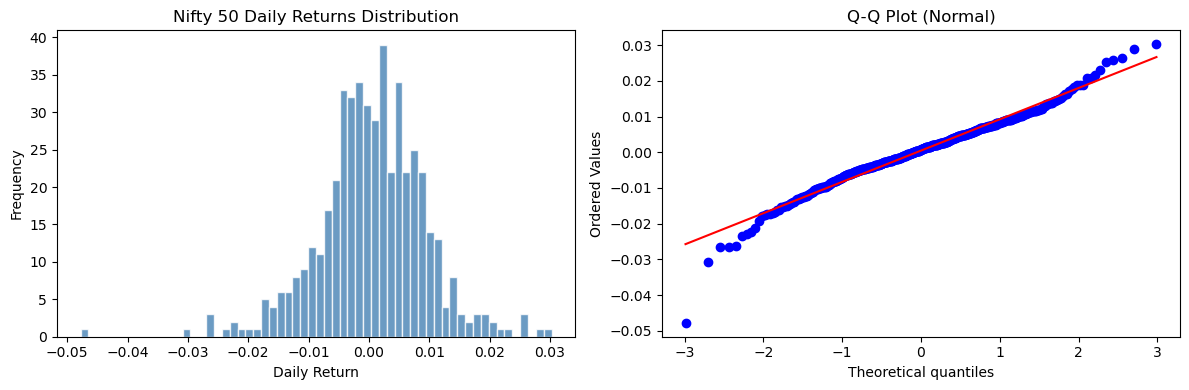

In [29]:
from scipy import stats
import matplotlib.pyplot as plt

# Use Nifty daily returns from Section 2
returns = nifty_returns.copy()

# --- Descriptive Stats ---
print("=== Nifty 50 Return Distribution ===")
print(f"Mean Daily Return : {returns.mean():.4%}")
print(f"Std Dev (Daily)   : {returns.std():.4%}")
print(f"Skewness          : {returns.skew():.2f}")
print(f"Kurtosis (excess) : {returns.kurt():.2f}")

# --- Jarque-Bera Test ---
jb_stat, jb_p = stats.jarque_bera(returns)
print(f"\nJarque-Bera Statistic : {jb_stat:.2f}")
print(f"p-value               : {jb_p:.6f}")
if jb_p < 0.05:
    print("Conclusion: Reject H0 — returns are NOT normally distributed")
else:
    print("Conclusion: Fail to reject H0 — returns appear normal")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(returns, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Nifty 50 Daily Returns Distribution")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Frequency")

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normal)")

plt.tight_layout()
plt.show()

## Section 4: Hypothesis Testing

### Key Concepts
- **H0 (Null Hypothesis):** The default assumption we are trying to disprove.
- **H1 (Alternative Hypothesis):** What we believe might be true instead.
- **p-value:** Probability of seeing your result *by chance* if H0 were true. p < 0.05 = reject H0.
- **One-sample t-test:** Tests whether the mean of a dataset is significantly different from a fixed value (e.g. is mean return ≠ 0?).
- **Two-sample t-test:** Tests whether the means of two groups are significantly different from each other.

In [30]:
from scipy import stats

# --- One-Sample t-test ---
# H0: Mean daily return of Nifty = 0 (market gives no return on average)
# H1: Mean daily return ≠ 0
t_stat, p_val = stats.ttest_1samp(nifty_returns, popmean=0)

print("=== One-Sample t-test: Is Nifty mean return = 0? ===")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.4f}")
if p_val < 0.05:
    print("Conclusion: Reject H0 — mean return is significantly different from 0")
else:
    print("Conclusion: Fail to reject H0 — cannot confirm mean return differs from 0")

# --- Two-Sample t-test ---
# H0: Mean return of Reliance = Mean return of Nifty
# H1: They are different
t_stat2, p_val2 = stats.ttest_ind(rel_returns, nifty_returns)

print("\n=== Two-Sample t-test: Reliance returns vs Nifty returns ===")
print(f"t-statistic : {t_stat2:.4f}")
print(f"p-value     : {p_val2:.4f}")
if p_val2 < 0.05:
    print("Conclusion: Reject H0 — returns are significantly different")
else:
    print("Conclusion: Fail to reject H0 — no significant difference in mean returns")

=== One-Sample t-test: Is Nifty mean return = 0? ===
t-statistic : 1.1638
p-value     : 0.2451
Conclusion: Fail to reject H0 — cannot confirm mean return differs from 0

=== Two-Sample t-test: Reliance returns vs Nifty returns ===
t-statistic : -0.0539
p-value     : 0.9570
Conclusion: Fail to reject H0 — no significant difference in mean returns


## Section 5: OLS Regression & Diagnostics

### Key Concepts
- **OLS (Ordinary Least Squares):** Fits a line through data by minimising the sum of squared errors between actual and predicted values.
- **R²:** How much of the variation in Y is explained by X. R²=1 means perfect fit.
- **Coefficients:** The slope tells us — for every 1 unit increase in X, Y changes by this amount.
- **5 OLS Assumptions:** Linearity, Homoscedasticity (constant variance), Normality of residuals, No autocorrelation, No multicollinearity.
- **Residuals:** The errors — difference between actual and predicted values. All diagnostics are about checking residual behaviour.

In [31]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

# Regress Reliance returns on Nifty returns (market model)
X = sm.add_constant(nifty_returns)   # add_constant adds the intercept column (β0)
y = rel_returns

model = sm.OLS(y, X).fit()
print(model.summary())

residuals = model.resid  # .resid extracts the leftover errors after fitting

# --- Key Diagnostics ---
dw = durbin_watson(residuals)  # Durbin-Watson: tests for autocorrelation in residuals. ~2 = no autocorrelation
jb_stat, jb_p, _, _ = sm.stats.stattools.jarque_bera(residuals)

print("\n=== Regression Diagnostics ===")
print(f"Durbin-Watson        : {dw:.2f}  (2.0 = ideal, no autocorrelation)")
print(f"Jarque-Bera p-value  : {jb_p:.4f}  ({'Residuals not normal' if jb_p < 0.05 else 'Residuals normal'})")

                            OLS Regression Results                            
Dep. Variable:            RELIANCE.NS   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     443.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.49e-70
Time:                        11:51:51   Log-Likelihood:                 1555.5
No. Observations:                 492   AIC:                            -3107.
Df Residuals:                     490   BIC:                            -3099.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.758e-05      0.000     -0.189      0.8

## Section 6: Time Series — Stationarity, ACF/PACF & ARIMA

### Key Concepts
- **Stationarity:** A time series is stationary if its mean and variance don't change over time. Most models require this.
- **ADF Test:** Augmented Dickey-Fuller test. H0 = series has a unit root (non-stationary). p < 0.05 = stationary.
- **ACF (Autocorrelation Function):** Measures correlation of a series with its own past values at various lags.
- **PACF (Partial ACF):** Like ACF but removes the effect of intermediate lags — helps identify AR order.
- **ARIMA(p,d,q):** p = autoregressive lags, d = differencing needed for stationarity, q = moving average lags.
- **Flat forecast:** ARIMA often predicts a flat line for financial returns — consistent with the Efficient Market Hypothesis (past prices can't predict future prices).

=== ADF Test: Nifty Price (levels) ===
ADF Statistic : 0.1714
p-value       : 0.9706
Conclusion    : Non-stationary (unit root present)

=== ADF Test: Nifty Returns (differenced) ===
ADF Statistic : -21.2651
p-value       : 0.0000
Conclusion    : Stationary


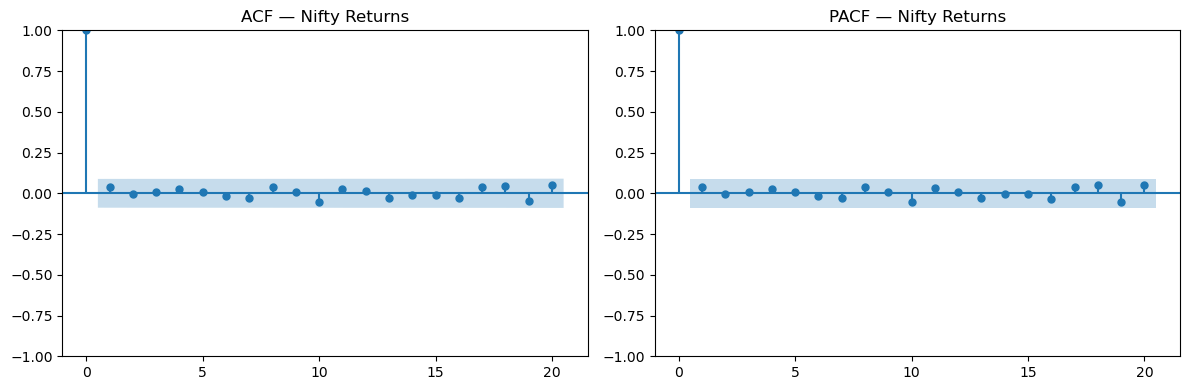


=== ARIMA(1,0,1) Forecast — Next 30 Days ===
492    0.000338
493    0.000470
494    0.000462
495    0.000463
496    0.000463
497    0.000463
498    0.000463
499    0.000463
500    0.000463
501    0.000463
502    0.000463
503    0.000463
504    0.000463
505    0.000463
506    0.000463
507    0.000463
508    0.000463
509    0.000463
510    0.000463
511    0.000463
512    0.000463
513    0.000463
514    0.000463
515    0.000463
516    0.000463
517    0.000463
518    0.000463
519    0.000463
520    0.000463
521    0.000463
Name: predicted_mean, dtype: float64


In [32]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Use Nifty price series (levels) and returns series
nifty_price = nifty.copy()

# --- ADF Test on Price (levels) ---
adf_price = adfuller(nifty_price)
print("=== ADF Test: Nifty Price (levels) ===")
print(f"ADF Statistic : {adf_price[0]:.4f}")
print(f"p-value       : {adf_price[1]:.4f}")
print("Conclusion    :", "Stationary" if adf_price[1] < 0.05 else "Non-stationary (unit root present)")

# --- ADF Test on Returns (differenced) ---
adf_ret = adfuller(nifty_returns)
print("\n=== ADF Test: Nifty Returns (differenced) ===")
print(f"ADF Statistic : {adf_ret[0]:.4f}")
print(f"p-value       : {adf_ret[1]:.4f}")
print("Conclusion    :", "Stationary" if adf_ret[1] < 0.05 else "Non-stationary")

# --- ACF / PACF Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(nifty_returns, lags=20, ax=axes[0], title="ACF — Nifty Returns")
plot_pacf(nifty_returns, lags=20, ax=axes[1], title="PACF — Nifty Returns")
plt.tight_layout()
plt.show()

# --- ARIMA(1,0,1) on returns ---
arima_model = ARIMA(nifty_returns, order=(1, 0, 1)).fit()
forecast = arima_model.forecast(steps=30)  # forecast: predicts next N values beyond the sample

print("\n=== ARIMA(1,0,1) Forecast — Next 30 Days ===")
print(forecast.round(6))

## Section 7: VAR & Granger Causality

### Key Concepts
- **VAR (Vector Autoregression):** Extends ARIMA to multiple time series simultaneously. Each variable is modelled as a function of its own past values AND the past values of all other variables in the system.
- **Lag Order:** How many past periods to include. Selected using AIC/BIC information criteria — lower is better.
- **Granger Causality:** Tests whether past values of series X help predict series Y, beyond what Y's own past already tells us. Important: "Granger causes" does NOT mean true causation — it means predictive usefulness.
- **H0 in Granger test:** X does NOT Granger-cause Y. p < 0.05 = X has predictive power over Y.

In [33]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Combine Nifty and Reliance returns into one DataFrame
var_data = pd.DataFrame({
    "Nifty": nifty_returns,
    "Reliance": rel_returns
}).dropna()

# --- Fit VAR model ---
var_model = VAR(var_data)
lag_result = var_model.select_order(maxlags=10)  # select_order: tries lags 1-10 and picks best by AIC
print("=== VAR Lag Order Selection ===")
print(lag_result.summary())

best_lag = lag_result.aic  # aic: Akaike Information Criterion — penalises complexity
fitted_var = var_model.fit(best_lag)
print(f"\nFitted VAR with {best_lag} lag(s)")

# --- Granger Causality ---
# Test: Does Nifty Granger-cause Reliance?
print("\n=== Granger Causality: Does Nifty → Reliance? ===")
granger_result = grangercausalitytests(var_data[["Reliance", "Nifty"]], maxlag=5, verbose=True)

=== VAR Lag Order Selection ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -18.59*     -18.57*  8.432e-09*     -18.58*
1       -18.58      -18.53   8.508e-09      -18.56
2       -18.57      -18.48   8.624e-09      -18.53
3       -18.56      -18.44   8.695e-09      -18.51
4       -18.56      -18.41   8.684e-09      -18.50
5       -18.55      -18.36   8.814e-09      -18.47
6       -18.54      -18.32   8.836e-09      -18.46
7       -18.53      -18.27   8.970e-09      -18.43
8       -18.52      -18.22   9.090e-09      -18.40
9       -18.53      -18.20   9.005e-09      -18.40
10      -18.52      -18.16   9.034e-09      -18.38
--------------------------------------------------

Fitted VAR with 0 lag(s)

=== Granger Causality: Does Nifty → Reliance? ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0483  , p=0.8262  , df_denom=488, df_num=1
ssr bas

## Summary — Block 1 + Block 2 Key Takeaways

| Concept | Key Finding |
|---|---|
| Financial Metrics | Reliance Sharpe=0.19, Beta=1.10 — market-like returns, slightly higher risk |
| Normality Testing | Nifty returns are NOT normal — fat tails, negative skew |
| Hypothesis Testing | Cannot statistically confirm Nifty mean return ≠ 0 over 2 years |
| OLS Regression | Nifty explains 47.5% of Reliance movement, Beta confirmed at 1.10 |
| Stationarity | Prices are non-stationary; returns are stationary |
| ARIMA Forecast | Flat forecast — consistent with Efficient Market Hypothesis |
| VAR + Granger | No predictive relationship between Nifty and Reliance returns |

> **Overarching theme:** Markets are largely efficient. Statistical tools confirm what theory predicts — past prices carry little predictive signal, returns are non-normal, and risk-adjusted performance is modest.